In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import numpy as np
import statsmodels.api as sm
from data_preprocessor import preprocessor
from statistics import t_test, t_test_binary_col, anova
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [2]:
font_path = "C:/Windows/Fonts/msjh.ttc"
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # 微軟正黑體
plt.rcParams['axes.unicode_minus'] = False  # 正負號也要支援中文

## 1. Data Preprocessing

In [3]:
df = pd.read_csv('LDA topics.csv')
a = preprocessor(df)
data, skill_cols, skill_set_cols, industry_cols = a.col_preprocess()

In [4]:
salary_data = data[(data['max_salary'] > 0)&(data['max_salary'] < 500000)&(data['salaryType'] != 'H')&(data['salaryType'] != 'D')].copy()
analyst_data = salary_data[(salary_data['topic_job_category']=='BA')|((salary_data['topic_job_category']=='DA')|((salary_data['topic_job_category']=='DS')))].copy()
print(len(salary_data), len(analyst_data))

349 157


## 2.  Regression 分析薪資天花板 - 主要技能 + 其他變數

In [5]:
sig_skills = [
    'skill_martech', 'skill_統計及ABTest', 'skill_視覺化&報表', 
    'skill_分析', 'skill_溝通&專案', 'skill_Coding', 'skill_策略', 
    'skill_商業智慧', 'skill_爬蟲',
    'skill_SQL','skill_客戶分群', 'skill_gcp', 'skill_解決問題', 
    'skill_顧客關係管理', 'skill_web 開發', 'skill_流程自動化', 
    'skill_set_ml_ai', 'skill_set_data_engineer', 'skill_set_llm_image'
]

In [6]:
x_cols = sig_skills + [
    'period', 'applyCnt', 'employees', 'is_remote', 'company_scale', 'education',
    'major_infomation', 'major_engineer', 'major_math_and_stats', 'major_commercial',
    'industry_電腦軟體相關產業', 'industry_電腦設備相關產業', 'industry_醫療業',
    'industry_工商顧問及其他專業', 'is_region_north'
]

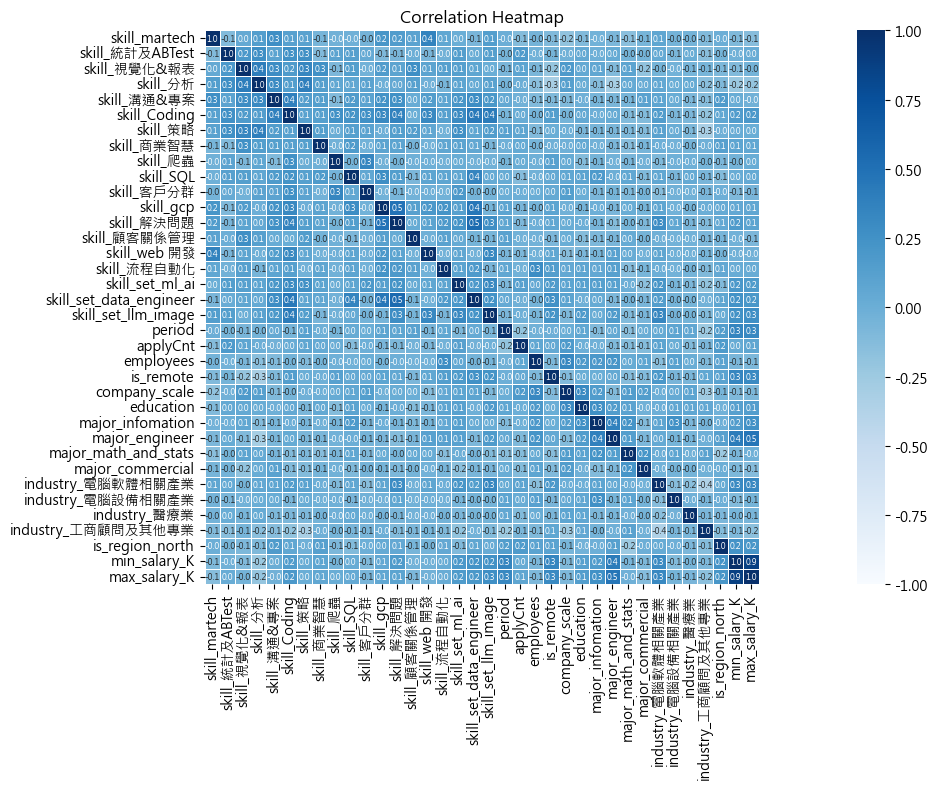

In [17]:
plt.figure(figsize=(20, 8))
sns.heatmap(
    analyst_data[x_cols + ['min_salary_K', 'max_salary_K']].corr(),
    annot=True,         # 顯示數字
    fmt=".1f",          # 顯示兩位小數
    cmap='Blues',    # 顏色範圍從藍到紅
    vmin=-1, vmax=1,    # 標準化顏色區間
    linewidths=0.5,
    square=True,
    annot_kws={"size": 6}
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [9]:
X = analyst_data[x_cols]
X = sm.add_constant(X)
y = analyst_data['log_max_salary']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         log_max_salary   R-squared:                       0.607
Model:                            OLS   Adj. R-squared:                  0.497
Method:                 Least Squares   F-statistic:                     5.540
Date:                Wed, 16 Apr 2025   Prob (F-statistic):           1.02e-12
Time:                        12:57:26   Log-Likelihood:                -18.643
No. Observations:                 157   AIC:                             107.3
Df Residuals:                     122   BIC:                             214.3
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

#### 檢查共線性

In [12]:
# 選擇用的變數
vif_df = pd.DataFrame()
vif_df['feature'] = X.columns
vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_df.sort_values(by='VIF', ascending=False)

,feature,VIF
0,const,28.103692
6,skill_Coding,2.611880
18,skill_set_data_engineer,2.513745
19,skill_set_llm_image,2.200128
13,skill_解決問題,2.193241
3,skill_視覺化&報表,2.045628
24,company_scale,2.034560
12,skill_gcp,1.992689
4,skill_分析,1.991054
33,industry_工商顧問及其他專業,1.889999


## 3. 用 Lasso 挑選變數

✅ Lasso 自動選出的重要變數：

major_engineer             0.137767
period                     0.136884
industry_電腦軟體相關產業          0.079718
applyCnt                   0.058738
is_remote                  0.058084
skill_set_data_engineer    0.038615
major_infomation           0.031589
skill_Coding               0.029639
skill_set_llm_image        0.020494
skill_商業智慧                 0.018235
is_region_north            0.004245
skill_流程自動化               -0.004777
skill_溝通&專案               -0.010104
skill_martech             -0.019780
employees                 -0.031401
dtype: float64


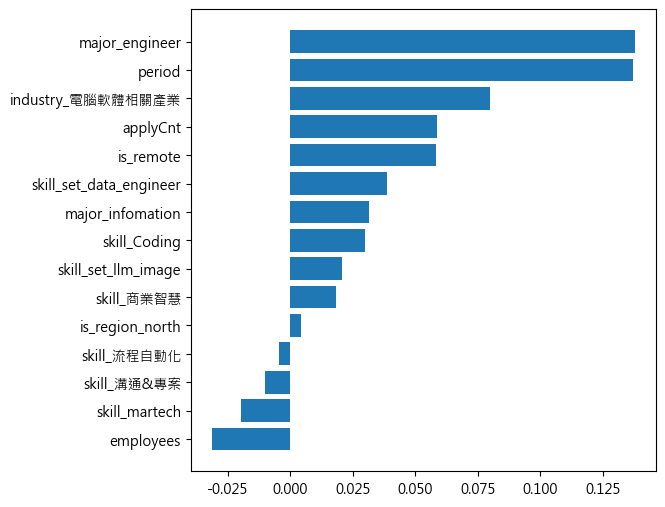

In [29]:
X = analyst_data[x_cols]
y = analyst_data['log_max_salary']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso = LassoCV(max_iter=50000, cv=5, random_state=42)
lasso.fit(X_scaled, y)

lasso_coef = pd.Series(lasso.coef_, index=x_cols)
important_features = lasso_coef[lasso_coef != 0].sort_values(ascending=False)

print("✅ Lasso 自動選出的重要變數：\n")
print(important_features)

important_features = pd.DataFrame(important_features, columns=['coef_'])

plt.figure(figsize=(6,6))
plt.barh(important_features.index, important_features['coef_'])
plt.gca().invert_yaxis()
plt.show()

In [30]:
lasso_x = important_features[important_features['coef_']>0].index
X = analyst_data[lasso_x]
X = sm.add_constant(X)
y = analyst_data['log_max_salary']

model = sm.OLS(y, X).fit()
print(model.summary())

# 檢查共線性
vif_df = pd.DataFrame()
vif_df['feature'] = X.columns
vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_df.sort_values(by='VIF', ascending=False)

                            OLS Regression Results                            
Dep. Variable:         log_max_salary   R-squared:                       0.530
Model:                            OLS   Adj. R-squared:                  0.495
Method:                 Least Squares   F-statistic:                     14.88
Date:                Wed, 16 Apr 2025   Prob (F-statistic):           5.22e-19
Time:                        13:06:02   Log-Likelihood:                -32.621
No. Observations:                 157   AIC:                             89.24
Df Residuals:                     145   BIC:                             125.9
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

,feature,VIF
0,const,6.667677
8,skill_Coding,1.475769
9,skill_set_llm_image,1.434197
6,skill_set_data_engineer,1.360680
1,major_engineer,1.296956
7,major_infomation,1.224713
3,industry_電腦軟體相關產業,1.173545
5,is_remote,1.128684
11,is_region_north,1.123812
2,period,1.120993


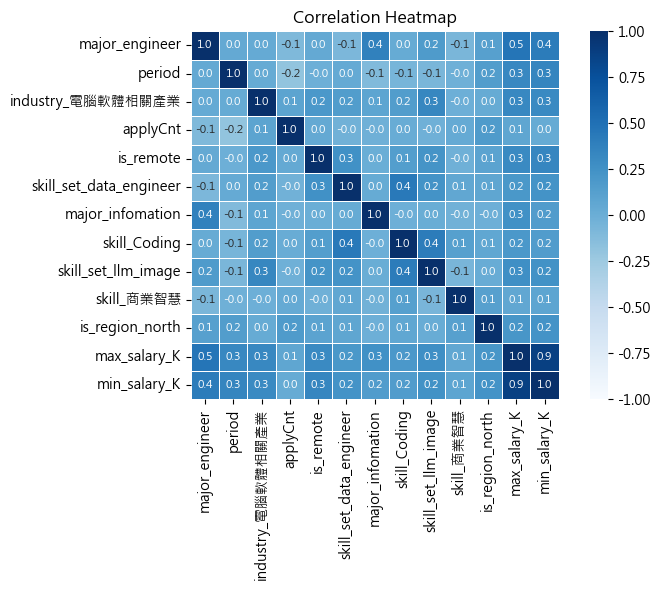

In [32]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    analyst_data[list(lasso_x)+['max_salary_K', 'min_salary_K']].corr(),
    annot=True,         # 顯示數字
    fmt=".1f",          # 顯示兩位小數
    cmap='Blues',    # 顏色範圍從藍到紅
    vmin=-1, vmax=1,    # 標準化顏色區間
    linewidths=0.5,
    square=True,
    annot_kws={"size": 8}
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

✅ Lasso 自動選出的重要變數：

major_engineer             0.114975
period                     0.110700
is_remote                  0.066527
industry_電腦軟體相關產業          0.053072
skill_set_data_engineer    0.043515
applyCnt                   0.034603
skill_商業智慧                 0.030096
is_region_north            0.020761
skill_set_llm_image        0.018260
skill_解決問題                 0.011213
education                  0.008726
skill_Coding               0.005915
skill_set_ml_ai            0.004130
major_infomation           0.002248
skill_SQL                 -0.005464
company_scale             -0.006632
skill_客戶分群                -0.009858
skill_web 開發              -0.013681
employees                 -0.015033
skill_分析                  -0.015500
skill_流程自動化               -0.015861
industry_電腦設備相關產業         -0.025792
dtype: float64


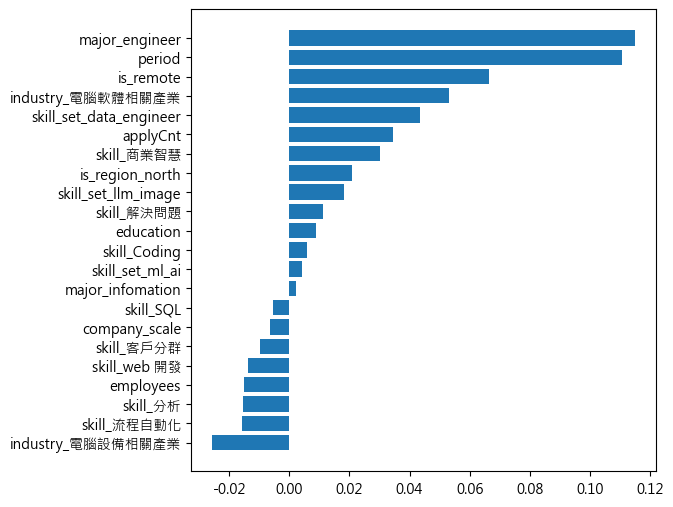

In [33]:
X = analyst_data[x_cols]
y = analyst_data['log_min_salary']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso = LassoCV(max_iter=50000, cv=5, random_state=42)
lasso.fit(X_scaled, y)

lasso_coef = pd.Series(lasso.coef_, index=x_cols)
important_features = lasso_coef[lasso_coef != 0].sort_values(ascending=False)

print("✅ Lasso 自動選出的重要變數：\n")
print(important_features)

important_features = pd.DataFrame(important_features, columns=['coef_'])

plt.figure(figsize=(6,6))
plt.barh(important_features.index, important_features['coef_'])
plt.gca().invert_yaxis()
plt.show()

In [34]:
lasso_x = important_features[important_features['coef_']>0].index
X = analyst_data[lasso_x]
X = sm.add_constant(X)
y = analyst_data['log_max_salary']

model = sm.OLS(y, X).fit()
print(model.summary())

# 檢查共線性
vif_df = pd.DataFrame()
vif_df['feature'] = X.columns
vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_df.sort_values(by='VIF', ascending=False)

                            OLS Regression Results                            
Dep. Variable:         log_max_salary   R-squared:                       0.534
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                     11.63
Date:                Wed, 16 Apr 2025   Prob (F-statistic):           1.65e-17
Time:                        13:07:14   Log-Likelihood:                -31.966
No. Observations:                 157   AIC:                             93.93
Df Residuals:                     142   BIC:                             139.8
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

,feature,VIF
0,const,13.670391
5,skill_set_data_engineer,1.713394
10,skill_解決問題,1.681898
9,skill_set_llm_image,1.554400
12,skill_Coding,1.522685
14,major_infomation,1.328297
1,major_engineer,1.324887
13,skill_set_ml_ai,1.297909
4,industry_電腦軟體相關產業,1.261235
8,is_region_north,1.170853


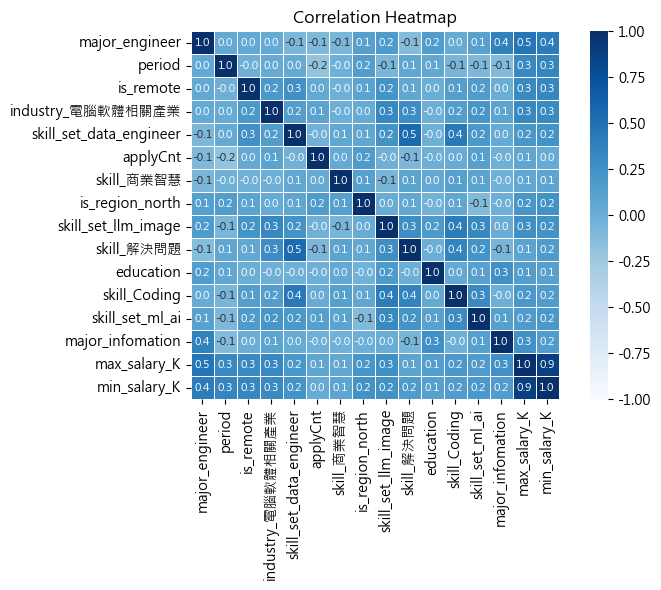

In [35]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    analyst_data[list(lasso_x)+['max_salary_K', 'min_salary_K']].corr(),
    annot=True,         # 顯示數字
    fmt=".1f",          # 顯示兩位小數
    cmap='Blues',    # 顏色範圍從藍到紅
    vmin=-1, vmax=1,    # 標準化顏色區間
    linewidths=0.5,
    square=True,
    annot_kws={"size": 8}
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()